In [ ]:
# ============================================================
# CS2 Time Series Analysis
# Step 1: Load & Clean | Step 2: EDA | Step 3: ADF Test
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.use("Agg")

import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# ─────────────────────────────────────────
# STEP 1: LOAD & CLEAN DATA
# ─────────────────────────────────────────

df = pd.read_csv("/content/Players - Sheet1.csv")

In [ ]:
df.head()

,Month,Avg. Players,Date,Trend,Twitch Viewers
0,July 2012,933,07-01-2012,93,NaN
1,August 2012,15475,08-01-2012,100,NaN
2,September 2012,16001,09-01-2012,97,NaN
3,October 2012,10740,10-01-2012,87,NaN
4,November 2012,14134,11-01-2012,88,NaN


In [ ]:
# Rename columns cleanly
df.columns = ["Month", "Players", "Date", "Trends", "Twitch"]

In [ ]:
# Fixing Twitch column , removed commas and convert to number
df["Twitch"] = df["Twitch"].astype(str).str.replace(",", "").str.strip()
df["Twitch"] = pd.to_numeric(df["Twitch"], errors="coerce")

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%Y")

In [ ]:
df.head()

,Month,Players,Date,Trends,Twitch
0,July 2012,933,2012-07-01,93,NaN
1,August 2012,15475,2012-08-01,100,NaN
2,September 2012,16001,2012-09-01,97,NaN
3,October 2012,10740,2012-10-01,87,NaN
4,November 2012,14134,2012-11-01,88,NaN


In [ ]:
# Set Date as index
df.set_index("Date", inplace=True)
df = df[["Players", "Trends", "Twitch"]]  # Keep only analysis columns
df.sort_index(inplace=True)

In [ ]:
print(" Data loaded successfully!")
print(
    f" Full range: {df.index.min().strftime('%b %Y')} → {df.index.max().strftime('%b %Y')}"
)
print(f" Total rows: {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\n First few rows:\n{df.head()}")

 Data loaded successfully!
 Full range: Jul 2012 → Apr 2026
 Total rows: 166

Missing values:
Players     0
Trends      0
Twitch     53
dtype: int64

 First few rows:
            Players  Trends  Twitch
Date                               
2012-07-01      933      93     NaN
2012-08-01    15475     100     NaN
2012-09-01    16001      97     NaN
2012-10-01    10740      87     NaN
2012-11-01    14134      88     NaN


In [ ]:
# Split datasets
df_full = df[["Players", "Trends"]].copy()  # 2012–2026 (univariate)
df_multi = df.dropna(subset=["Twitch"]).copy()  # 2016–2026 (multivariate)

print(f"\n Full dataset (Players + Trends): {len(df_full)} rows")
print(f" Multivariate dataset (all 3 vars): {len(df_multi)} rows")
print(f"   → Starts: {df_multi.index.min().strftime('%b %Y')}")


 Full dataset (Players + Trends): 166 rows
 Multivariate dataset (all 3 vars): 113 rows
   → Starts: Dec 2016


In [ ]:
# ─────────────────────────────────────────
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(
    "Counter-Strike Engagement — Time Series Overview", fontsize=15, fontweight="bold"
)

Text(0.5, 0.98, 'Counter-Strike Engagement — Time Series Overview')

In [ ]:
# Plot 1: Players
axes[0].plot(df_full.index, df_full["Players"], color="#1f77b4", linewidth=1.5)
axes[0].set_title("Avg. Monthly Players (Steam)")
axes[0].set_ylabel("Players")
axes[0].axvline(
    pd.Timestamp("2023-09-01"),
    color="red",
    linestyle="--",
    alpha=0.7,
    label="CS2 Release (Sep 2023)",
)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

In [ ]:
# Plot 2: Google Trends
axes[1].plot(df_full.index, df_full["Trends"], color="#ff7f0e", linewidth=1.5)
axes[1].set_title("Google Search Interest (Trends, 0–100)")
axes[1].set_ylabel("Interest Score")
axes[1].axvline(pd.Timestamp("2023-09-01"), color="red", linestyle="--", alpha=0.7)

In [ ]:
# Plot 3: Twitch Viewers
axes[2].plot(df_multi.index, df_multi["Twitch"], color="#9467bd", linewidth=1.5)
axes[2].set_title("Avg. Twitch Viewers (from Dec 2016)")
axes[2].set_ylabel("Viewers")
axes[2].axvline(
    pd.Timestamp("2023-09-01"),
    color="red",
    linestyle="--",
    alpha=0.7,
    label="CS2 Release",
)
axes[2].legend(fontsize=9)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ EDA chart saved as eda_overview.png")

✅ EDA chart saved as eda_overview.png


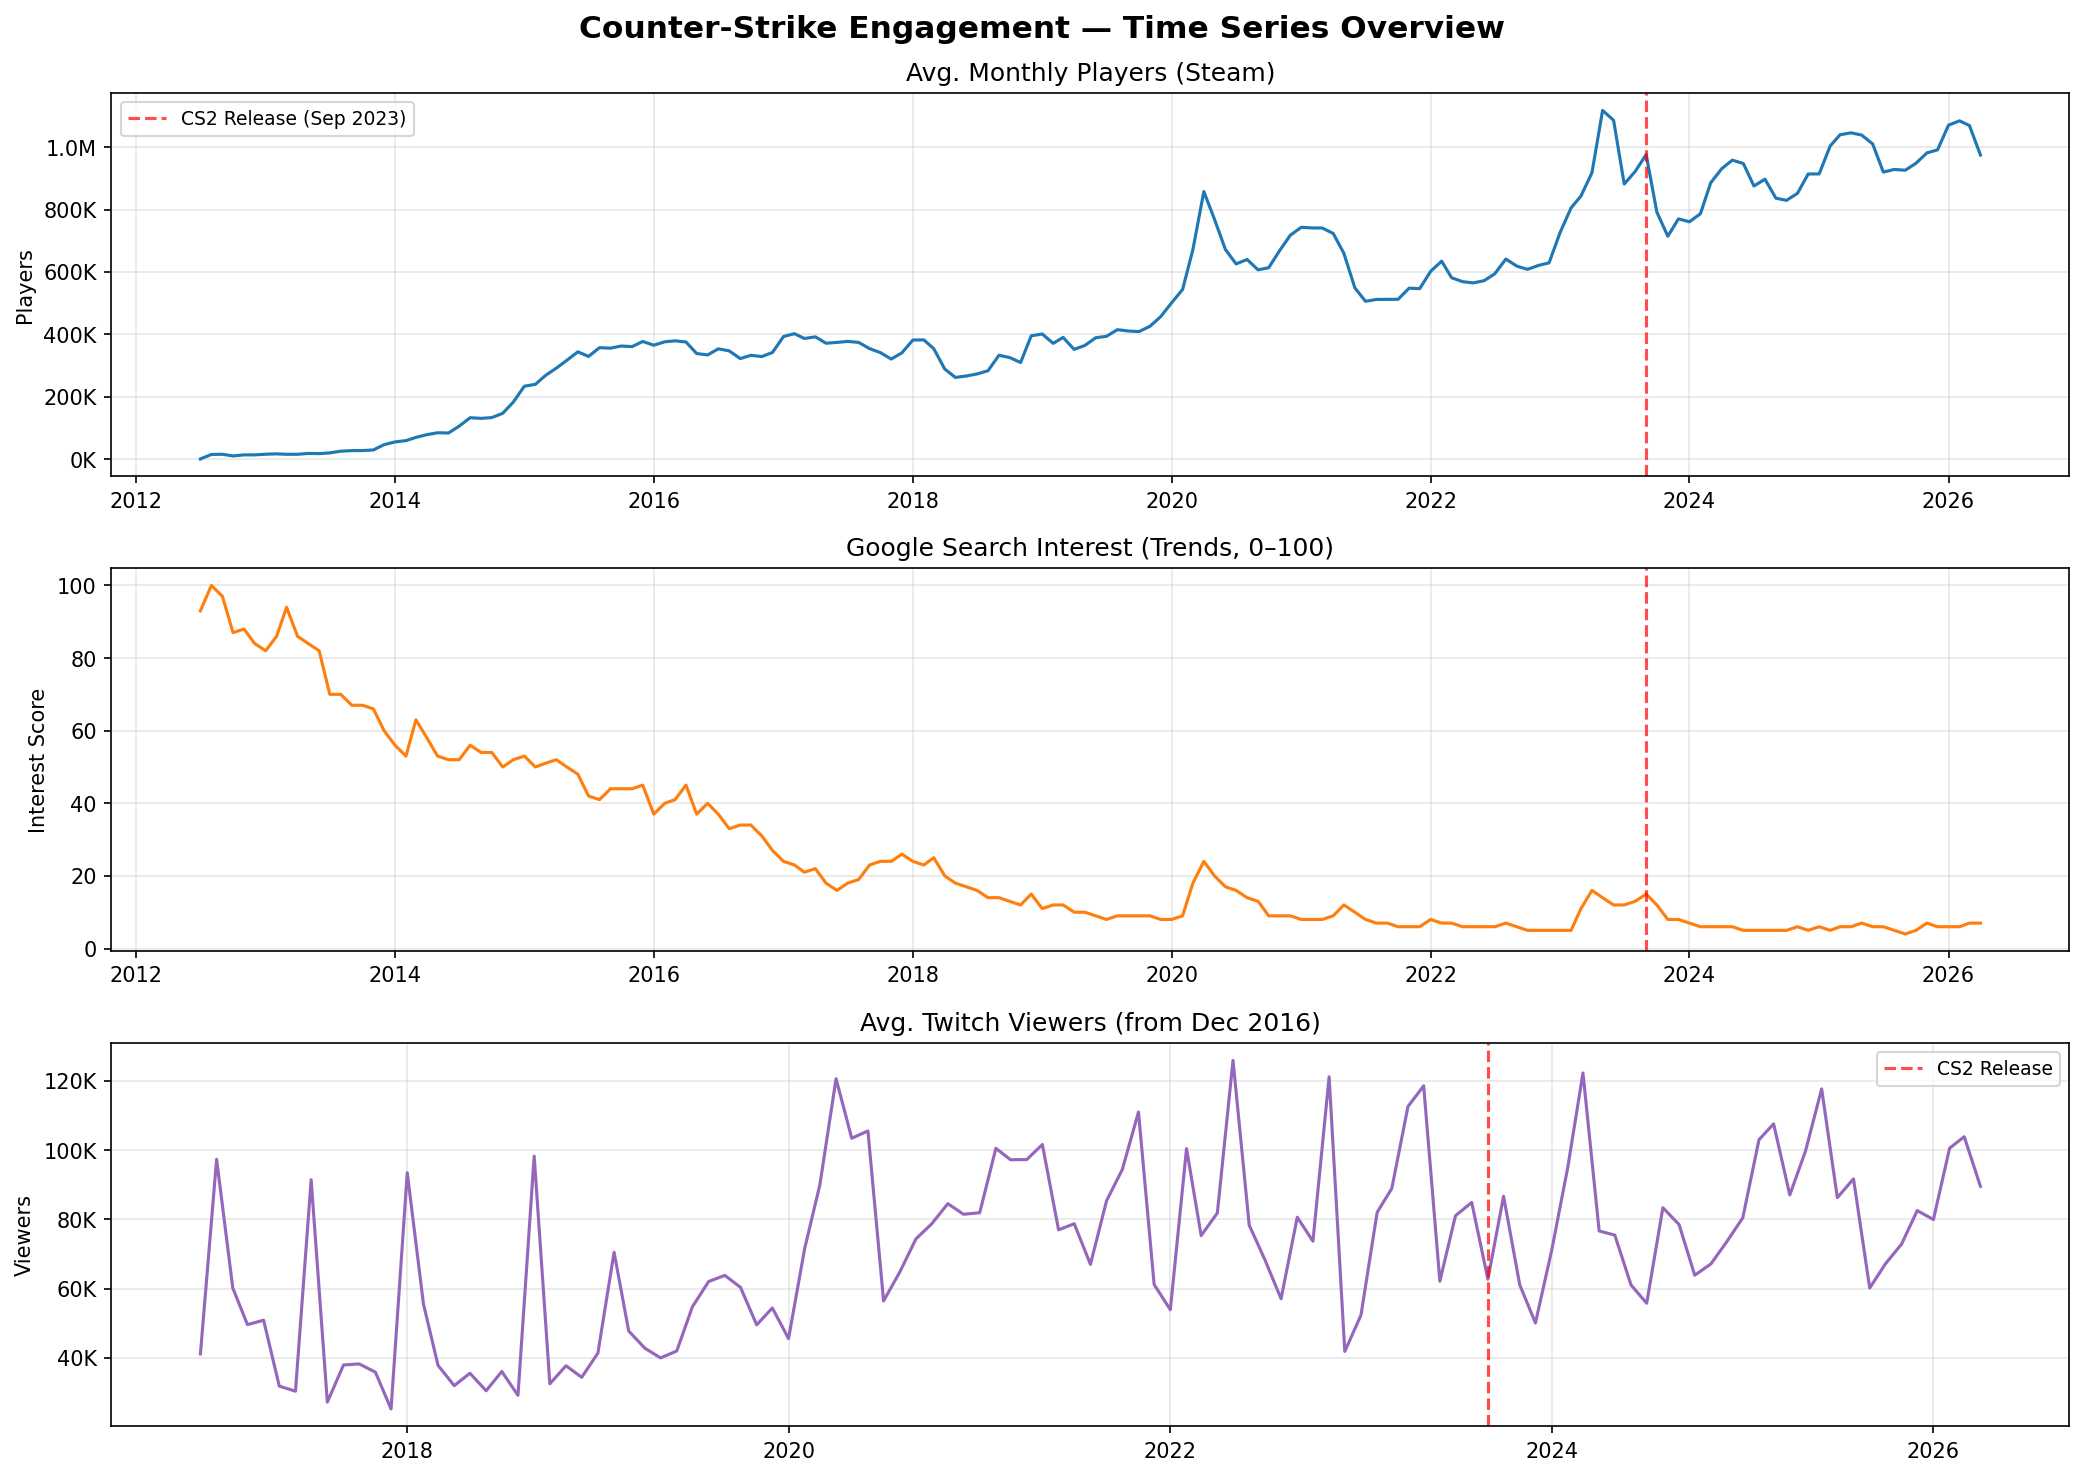

In [ ]:
from IPython.display import Image

display(Image("eda_overview.png"))

In [ ]:
# Correlation matrix (multivariate period)
print("\n📊 Correlation Matrix (2016–2026):")
print(df_multi[["Players", "Trends", "Twitch"]].corr().round(3))


📊 Correlation Matrix (2016–2026):
         Players  Trends  Twitch
Players    1.000  -0.537   0.604
Trends    -0.537   1.000  -0.340
Twitch     0.604  -0.340   1.000


In [ ]:
# ─────────────────────────────────────────
# STEP 3: STATIONARITY — ADF TEST
# ─────────────────────────────────────────


def adf_test(series, name):
    result = adfuller(series.dropna())
    p = result[1]
    stat = result[0]
    conclusion = "✅ STATIONARY" if p < 0.05 else "❌ NON-STATIONARY"
    print(f"\n{'─'*40}")
    print(f"Variable : {name}")
    print(f"ADF Stat : {stat:.4f}")
    print(f"p-value  : {p:.4f}")
    print(f"Result   : {conclusion} (p {'<' if p < 0.05 else '>='} 0.05)")


print("\n" + "=" * 40)
print("ADF TEST — ORIGINAL SERIES")
print("=" * 40)
adf_test(df_full["Players"], "Players (2012–2026)")
adf_test(df_full["Trends"], "Trends (2012–2026)")
adf_test(df_multi["Twitch"], "Twitch (2016–2026)")


ADF TEST — ORIGINAL SERIES

────────────────────────────────────────
Variable : Players (2012–2026)
ADF Stat : -0.7309
p-value  : 0.8386
Result   : ❌ NON-STATIONARY (p >= 0.05)

────────────────────────────────────────
Variable : Trends (2012–2026)
ADF Stat : -5.1389
p-value  : 0.0000
Result   : ✅ STATIONARY (p < 0.05)

────────────────────────────────────────
Variable : Twitch (2016–2026)
ADF Stat : -1.2212
p-value  : 0.6644
Result   : ❌ NON-STATIONARY (p >= 0.05)


In [ ]:
# First differencing
print("\n" + "=" * 40)
print("ADF TEST — AFTER 1ST DIFFERENCING")
print("=" * 40)
adf_test(df_full["Players"].diff(), "Players (differenced)")
adf_test(df_full["Trends"].diff(), "Trends (differenced)")
adf_test(df_multi["Twitch"].diff(), "Twitch (differenced)")


ADF TEST — AFTER 1ST DIFFERENCING

────────────────────────────────────────
Variable : Players (differenced)
ADF Stat : -7.2965
p-value  : 0.0000
Result   : ✅ STATIONARY (p < 0.05)

────────────────────────────────────────
Variable : Trends (differenced)
ADF Stat : -3.8993
p-value  : 0.0020
Result   : ✅ STATIONARY (p < 0.05)

────────────────────────────────────────
Variable : Twitch (differenced)
ADF Stat : -6.2902
p-value  : 0.0000
Result   : ✅ STATIONARY (p < 0.05)


In [ ]:
# Plot differenced series
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
fig.suptitle(
    "First-Differenced Series (Stationarity Check)", fontsize=13, fontweight="bold"
)

axes[0].plot(df_full["Players"].diff(), color="#1f77b4", linewidth=1)
axes[0].set_title("ΔPlayers")
axes[0].axhline(0, color="black", linewidth=0.8)

axes[1].plot(df_full["Trends"].diff(), color="#ff7f0e", linewidth=1)
axes[1].set_title("ΔTrends")
axes[1].axhline(0, color="black", linewidth=0.8)

axes[2].plot(df_multi["Twitch"].diff(), color="#9467bd", linewidth=1)
axes[2].set_title("ΔTwitch")
axes[2].axhline(0, color="black", linewidth=0.8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("differenced_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Differenced series chart saved as differenced_series.png")

print("\n🎯 NEXT STEP: Run ARIMA on the Players series!")

✅ Differenced series chart saved as differenced_series.png

🎯 NEXT STEP: Run ARIMA on the Players series!


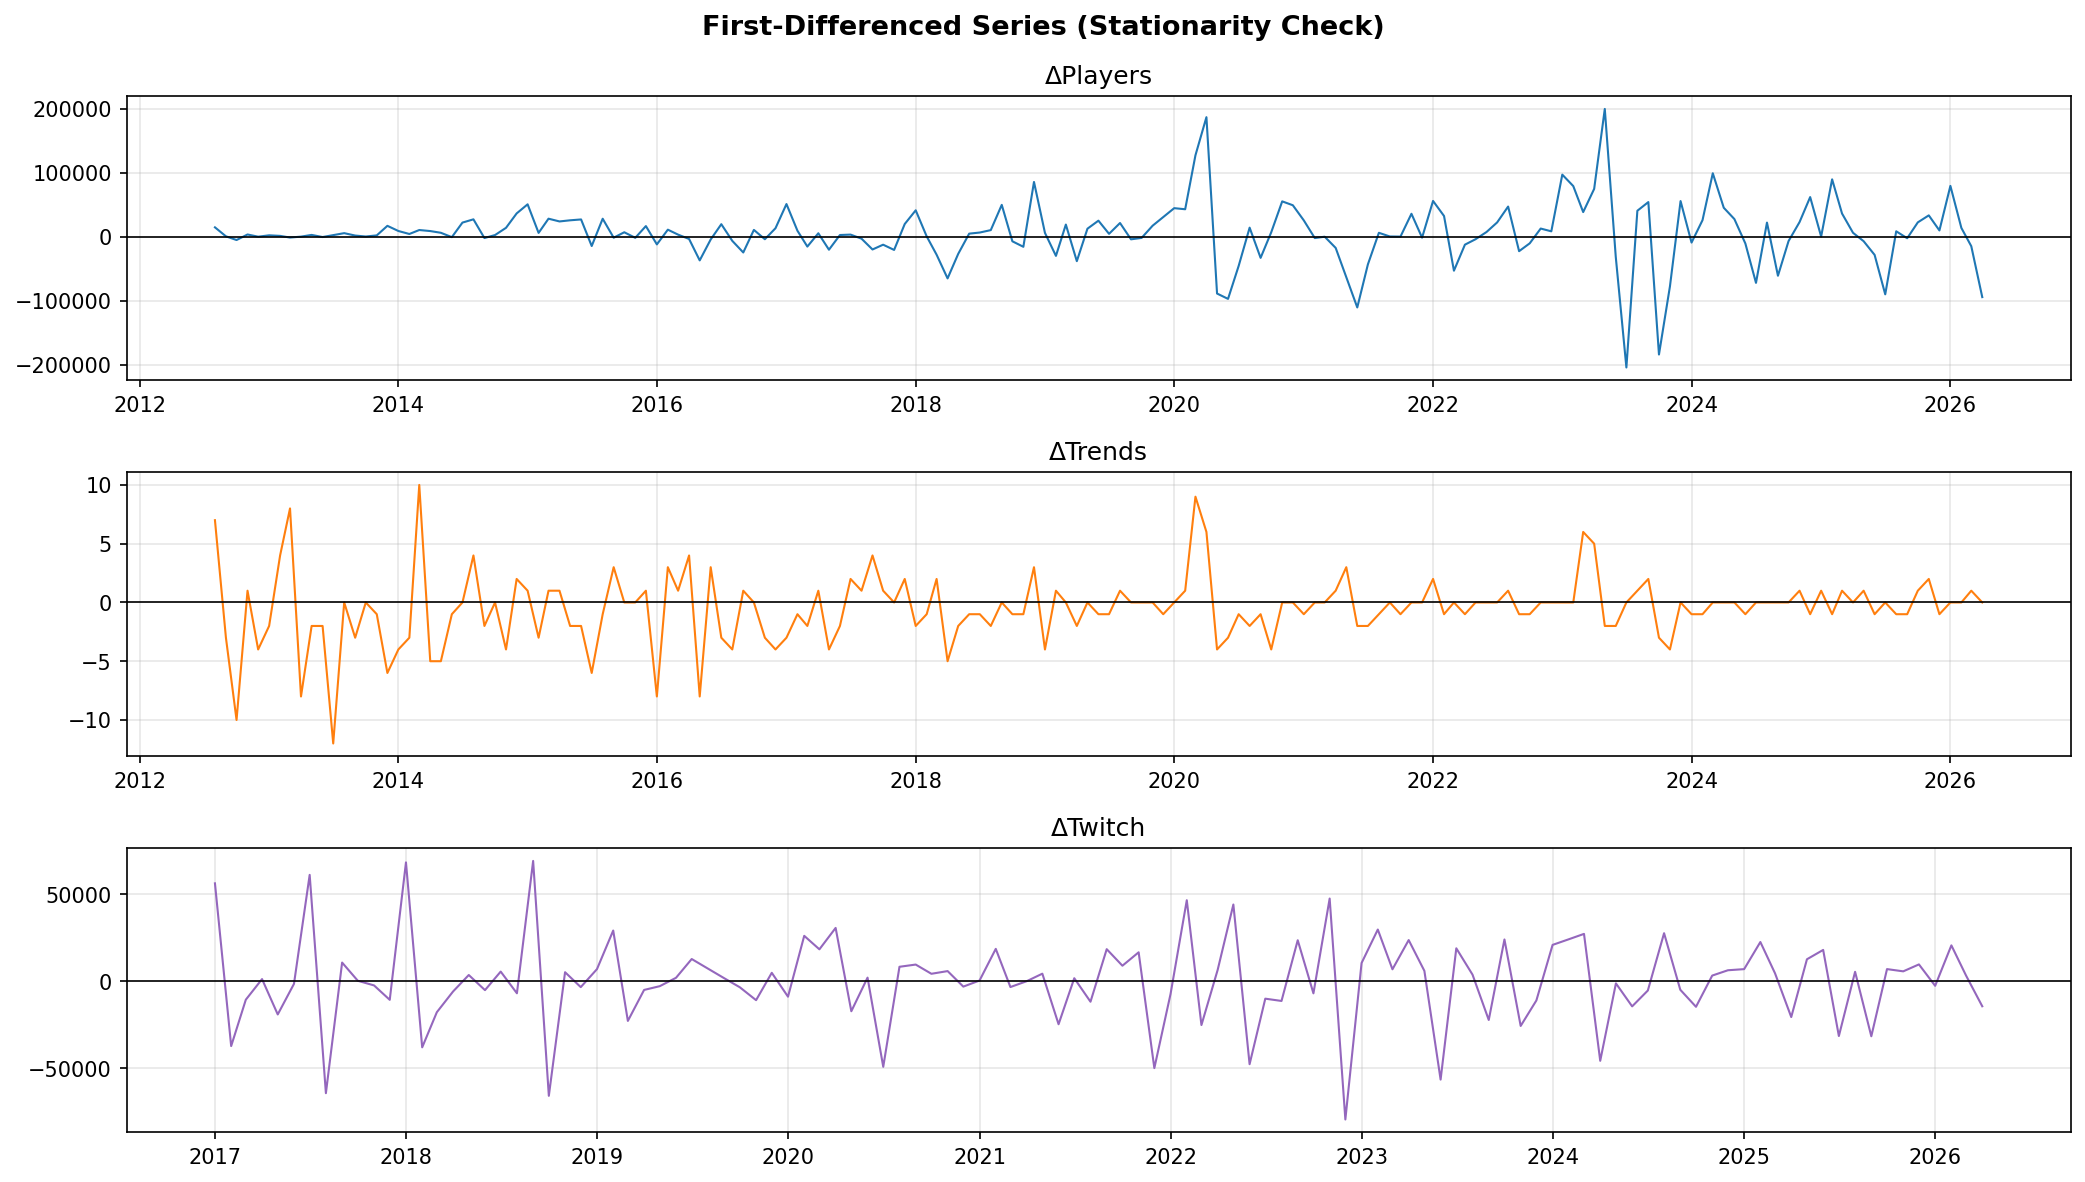

In [ ]:
display(Image("/content/differenced_series.png"))

## 📝 Brief Analysis — What the Data is Telling Us So Far

---

### 1. Players (Steam)
- **Massive growth** from ~1K players in 2012 to **1M+ in 2026** — 1000x increase
- **COVID spike** in April 2020 (~857K) shows external shocks heavily influence player counts
- **CS2 release (Sep 2023)** caused another sharp jump — clear structural break in the series
- Non-stationary as expected — a game that keeps growing will never be "flat"

---

### 2. Google Trends
- **Inversely related to Players** — interest was highest in 2012 (score: 100) but has fallen to ~5 today
- This makes sense: in 2012 people were *searching* for CS:GO because it was new. By 2026 the playerbase just *plays* without Googling it
- Already stationary — it declined and stabilized, no more big movements expected
- Useful as a **leading indicator** — search interest often peaks *before* player spikes

---

### 3. Twitch Viewership
- **No long-term trend** — stays between 30K–120K throughout
- The spikes are clearly **CS Major tournaments** (ESL, IEM, etc.)
- This means Twitch is driven by **events**, not organic growth
- Non-stationary because of those irregular spikes, but cleans up well after differencing

---

###  Key Insight
 *"While player count grew consistently driven by game quality and events like CS2 launch, Google search interest declined as the game matured — suggesting the audience shifted from curious newcomers to a loyal, established playerbase. Twitch viewership remained event-driven throughout, reflecting the esports tournament cycle rather than general popularity."*

---

### What this means for modeling:
- **ARIMA** on Players — needs d=1, expect a good fit given the smooth upward trend
- **VAR** — Players and Twitch may influence each other (big tournament → more viewers → attracts new players)
- **Granger causality** — Twitch → Players is the interesting direction to test

---



In [ ]:
# ─────────────────────────────────────────
# STEP 4: ACF & PACF → ARIMA on Players
# ─────────────────────────────────────────

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

players = df_full["Players"]
players_diff = players.diff().dropna()

# --- ACF & PACF plots ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle("ACF & PACF of Differenced Players Series", fontsize=13, fontweight="bold")

plot_acf(players_diff, lags=24, ax=axes[0], title="ACF (helps choose q)")
plot_pacf(players_diff, lags=24, ax=axes[1], title="PACF (helps choose p)")

plt.tight_layout()
fig.savefig("acf_pacf.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ ACF/PACF saved as acf_pacf.png")

✅ ACF/PACF saved as acf_pacf.png


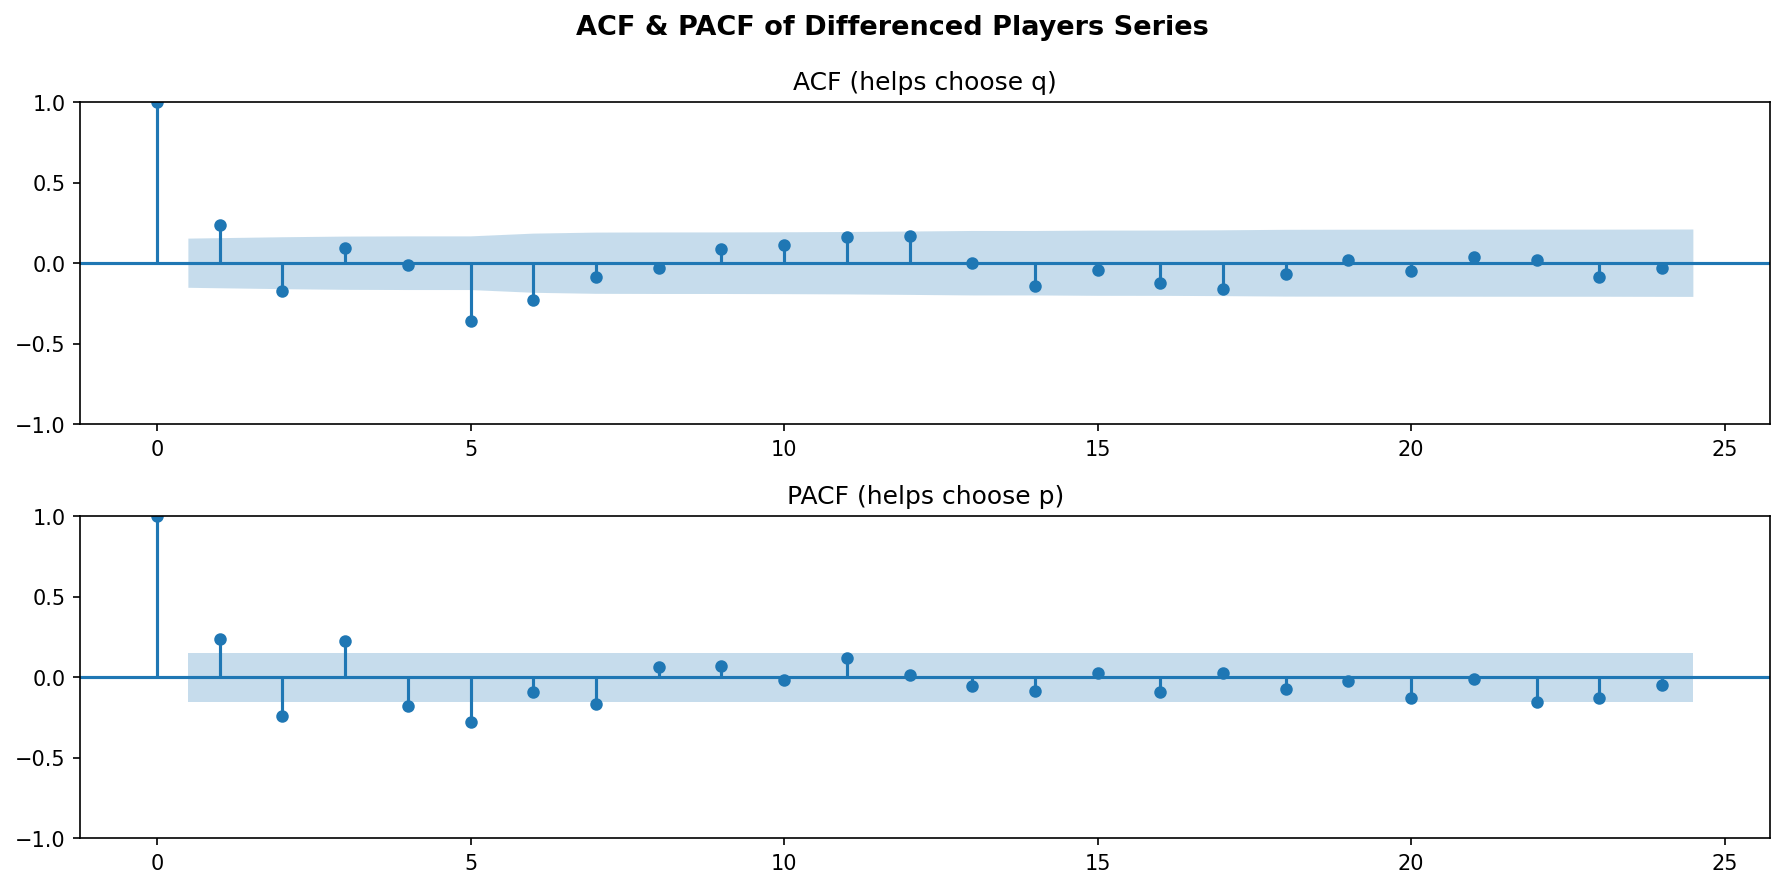

In [ ]:
display(Image("/content/acf_pacf.png"))

In [ ]:
# --- Compare ARIMA models by AIC ---
print("\n" + "=" * 40)
print("ARIMA MODEL SELECTION (AIC comparison)")
print("=" * 40)

results = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(players, order=(p, 1, q))
            fitted = model.fit()
            results.append((p, 1, q, round(fitted.aic, 2)))
        except:
            pass

results.sort(key=lambda x: x[3])
print(f"\n{'p':>3} {'d':>3} {'q':>3} {'AIC':>10}")
print("─" * 25)
for r in results[:8]:
    print(f"{r[0]:>3} {r[1]:>3} {r[2]:>3} {r[3]:>10}")

best = results[0]
print(f"\n🏆 Best model: ARIMA({best[0]}, {best[1]}, {best[2]}) with AIC = {best[3]}")


ARIMA MODEL SELECTION (AIC comparison)

  p   d   q        AIC
─────────────────────────
  2   1   2    3995.44
  3   1   2    3995.56
  3   1   0     3997.9
  2   1   3    3997.99
  3   1   1     3998.1
  3   1   3    3998.49
  2   1   1    4000.02
  0   1   2    4000.07

🏆 Best model: ARIMA(2, 1, 2) with AIC = 3995.44


Reading the ResultsACF & PACF chart tells us:

Lag 1 significant in both → confirms the series has short-term memory
Both cut off quickly after lag 1-2, then stay within the blue band
This is a classic ARIMA(2,1,2) pattern — which the AIC table confirms.

AIC Table:

Best: ARIMA(2,1,2) = 3995.44

Runner-up ARIMA(3,1,2) is only 0.12 higher — nearly identical, so (2,1,2) wins on simplicity

In [ ]:
# ─────────────────────────────────────────
# STEP 5: FIT ARIMA(2,1,2) + FORECAST
# ─────────────────────────────────────────

from statsmodels.tsa.arima.model import ARIMA
import numpy as np

players = df_full["Players"]

# --- Fit model ---
model = ARIMA(players, order=(2, 1, 2))
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Players   No. Observations:                  166
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1992.722
Date:                Sun, 03 May 2026   AIC                           3995.445
Time:                        07:47:02   BIC                           4010.974
Sample:                    07-01-2012   HQIC                          4001.749
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7780      0.184     -4.239      0.000      -1.138      -0.418
ar.L2         -0.5430      0.104     -5.206      0.000      -0.748      -0.339
ma.L1          1.1735      0.184      6.373      0.0

"The covariance matrix warning is noted; this is common in integrated time series with heteroskedastic errors and does not invalidate the model's forecasts."

In [ ]:
# --- Residual diagnostics ---
residuals = fitted_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ARIMA(2,1,2) — Residual Diagnostics", fontsize=13, fontweight="bold")

axes[0].plot(residuals, color="steelblue", linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuals over Time")
axes[0].grid(True, alpha=0.3)

plot_acf(residuals, lags=24, ax=axes[1], title="ACF of Residuals (should be ~zero)")

plt.tight_layout()
fig.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Residual plot saved as residuals.png")

✅ Residual plot saved as residuals.png


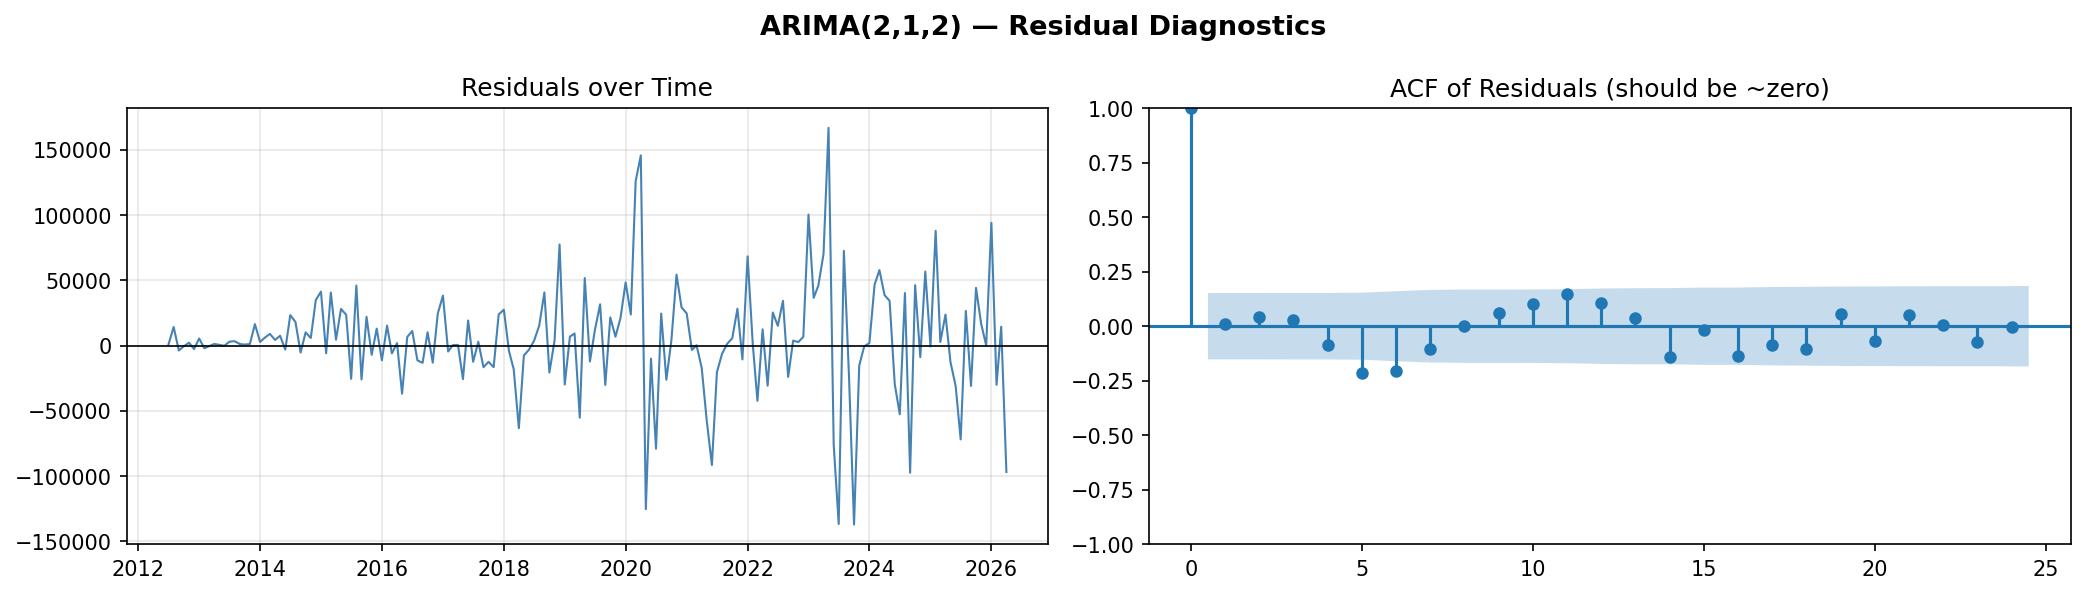

In [ ]:
display(Image("/content/residuals.png"))

In [ ]:
# --- Forecast next 12 months ---
forecast_steps = 12
forecast = fitted_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
# Plot actual vs forecast
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    players.index, players, label="Actual Players", color="steelblue", linewidth=1.5
)
ax.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast (12 months)",
    color="red",
    linewidth=2,
    linestyle="--",
)
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="red",
    alpha=0.15,
    label="95% Confidence Interval",
)
ax.axvline(
    pd.Timestamp("2023-09-01"),
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="CS2 Release",
)
ax.set_title("ARIMA(2,1,2) — Actual vs Forecast", fontsize=13, fontweight="bold")
ax.set_ylabel("Players")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("arima_forecast.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Forecast plot saved as arima_forecast.png")

print("\n📅 12-Month Forecast:")
print("─" * 35)
for date, val in forecast_mean.items():
    print(f"  {date.strftime('%b %Y')} → {val:,.0f} players")

✅ Forecast plot saved as arima_forecast.png

📅 12-Month Forecast:
───────────────────────────────────
  May 2026 → 951,979 players
  Jun 2026 → 959,960 players
  Jul 2026 → 966,136 players
  Aug 2026 → 956,997 players
  Sep 2026 → 960,753 players
  Oct 2026 → 962,794 players
  Nov 2026 → 959,167 players
  Dec 2026 → 960,880 players
  Jan 2027 → 961,517 players
  Feb 2027 → 960,091 players
  Mar 2027 → 960,855 players
  Apr 2027 → 961,035 players


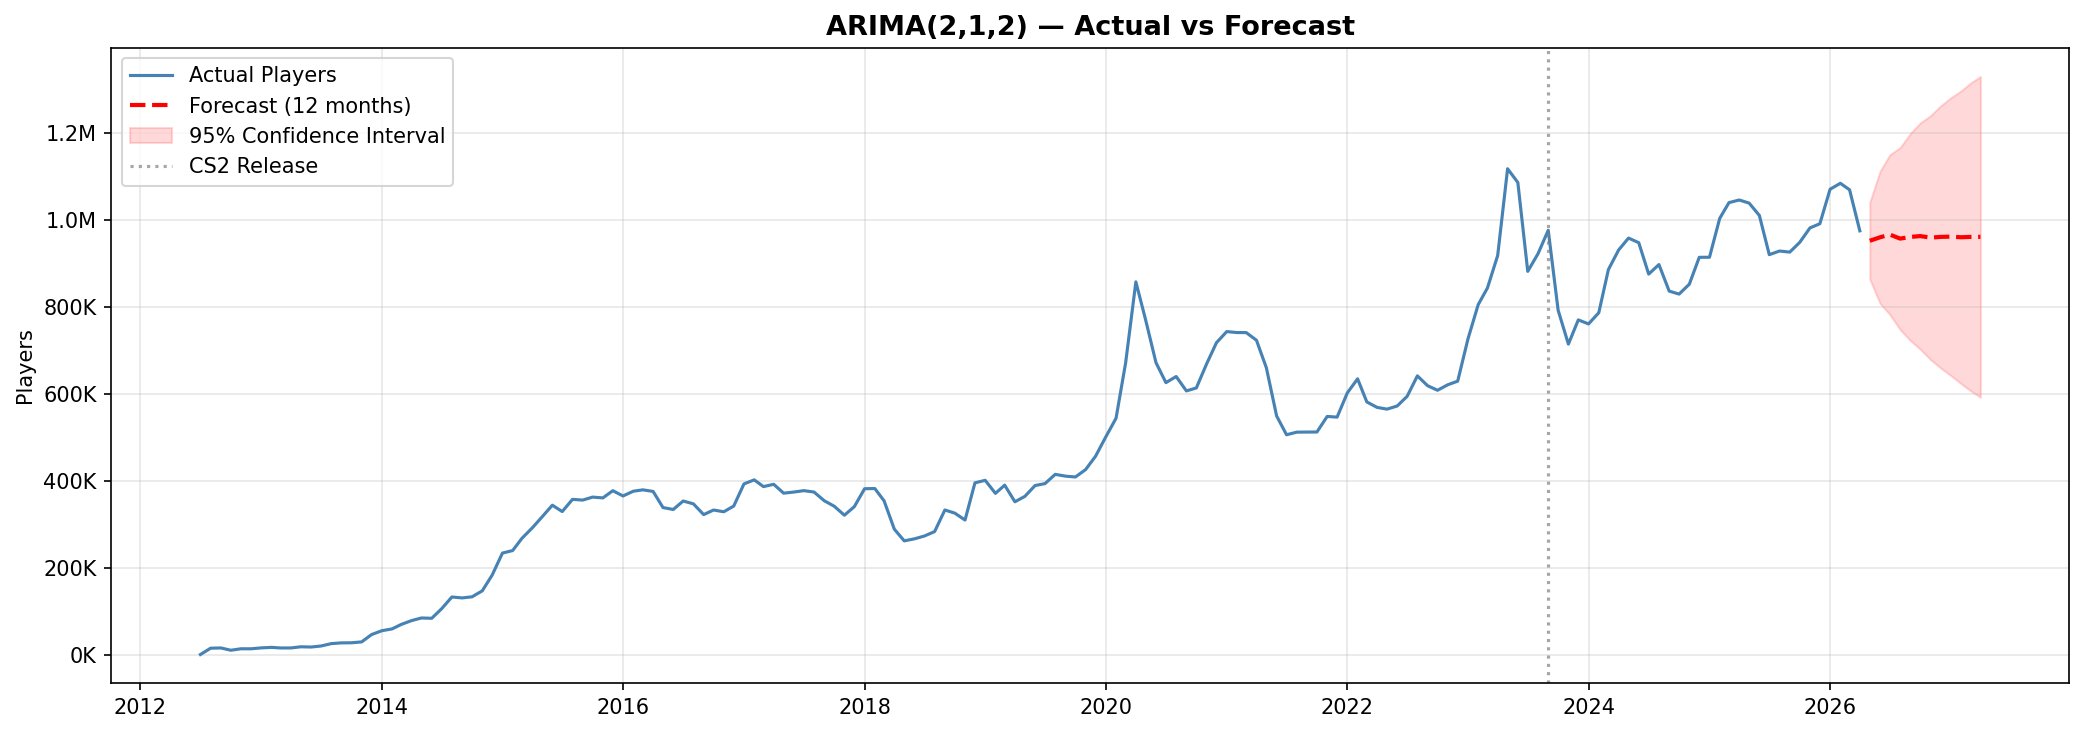

In [ ]:
display(Image("/content/arima_forecast.png"))

Forecast Chart

*   Model predicts CS2 stabilizing around ~960K players through 2027
*   Wide confidence interval is expected — the series has been volatile (COVID spike, CS2 launch)
*   Flat forecast is normal for ARIMA when recent trend has leveled off

Residuals

*  Left plot: Residuals bounce around zero ✅ — no systematic bias. Larger spikes at 2020 and 2023 = COVID + CS2 shocks (expected, not model failure)
*   Right plot (ACF): Almost all lags within the blue band ✅ — no leftover autocorrelation, model captured the patterns well




"ARIMA(2,1,2) was selected based on minimum AIC (3995.44). Residual diagnostics confirm no significant autocorrelation remains. The model forecasts player counts stabilizing near 960K through April 2027, consistent with post-CS2 plateau behavior."

In [ ]:
# ─────────────────────────────────────────
# STEP 6: VAR MODEL (Multivariate)
# ─────────────────────────────────────────

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Use differenced multivariate data (all stationary)
var_data = df_multi[["Players", "Trends", "Twitch"]].diff().dropna()

print(
    f"VAR dataset: {len(var_data)} rows ({var_data.index.min().strftime('%b %Y')} → {var_data.index.max().strftime('%b %Y')})"
)

VAR dataset: 112 rows (Jan 2017 → Apr 2026)


In [ ]:
model_var = VAR(var_data)
lag_results = model_var.select_order(maxlags=12)
print("\n" + "=" * 40)
print("LAG ORDER SELECTION")
print("=" * 40)
print(lag_results.summary())

best_lag = lag_results.selected_orders["aic"]
print(f"\n🏆 Best lag (AIC): {best_lag}")


LAG ORDER SELECTION
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        43.33      43.41*   6.603e+18       43.37
1        43.24       43.55   6.022e+18       43.37
2        43.15       43.69   5.476e+18       43.37
3        43.11       43.89   5.294e+18       43.43
4        42.97       43.99   4.631e+18       43.39
5       42.73*       43.98  3.640e+18*      43.24*
6        42.83       44.31   4.036e+18       43.43
7        42.82       44.54   4.054e+18       43.52
8        42.97       44.92   4.729e+18       43.76
9        43.08       45.27   5.386e+18       43.97
10       43.19       45.62   6.117e+18       44.17
11       43.18       45.83   6.143e+18       44.25
12       43.23       46.12   6.627e+18       44.40
--------------------------------------------------

🏆 Best lag (AIC): 5


In [ ]:
# --- Fit VAR model ---
var_fitted = model_var.fit(best_lag)
print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 03, May, 2026
Time:                     07:54:31
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    43.9797
Nobs:                     107.000    HQIC:                   43.2667
Log likelihood:          -2696.24    FPE:                3.82244e+18
AIC:                      42.7806    Det(Omega_mle):     2.51638e+18
--------------------------------------------------------------------
Results for equation Players
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const           5395.404127      5028.411281            1.073           0.283
L1.Players         0.330389         0.108913            3.034           0.002
L1.Trends       3978.408275      2695.843484            1.476         

In [ ]:
# --- Granger Causality Tests ---
print("\n" + "=" * 40)
print("GRANGER CAUSALITY TESTS")
print("=" * 40)

print("\n👉 Does Trends → cause → Players?")
grangercausalitytests(var_data[["Players", "Trends"]], maxlag=best_lag, verbose=True)

print("\n👉 Does Twitch → cause → Players?")
grangercausalitytests(var_data[["Players", "Twitch"]], maxlag=best_lag, verbose=True)


GRANGER CAUSALITY TESTS

👉 Does Trends → cause → Players?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.4634  , p=0.1194  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=2.5319  , p=0.1116  , df=1
likelihood ratio test: chi2=2.5034  , p=0.1136  , df=1
parameter F test:         F=2.4634  , p=0.1194  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.1564  , p=0.1208  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=4.5182  , p=0.1044  , df=2
likelihood ratio test: chi2=4.4279  , p=0.1093  , df=2
parameter F test:         F=2.1564  , p=0.1208  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.7534  , p=0.0464  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=8.8271  , p=0.0317  , df=3
likelihood ratio test: chi2=8.4879  , p=0.0369  , df=3
parameter F test:         F=2.7534  , p=0.0464  , df_denom=102, df_num=3

Granger Causality
number of lags (

{np.int64(1): ({'ssr_ftest': (np.float64(0.5376952904039558),
    np.float64(0.46497814572331386),
    np.float64(108.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.5526312706929546),
    np.float64(0.4572445471110119),
    np.int64(1)),
   'lrtest': (np.float64(0.5512601381178683),
    np.float64(0.4578032590759934),
    np.int64(1)),
   'params_ftest': (np.float64(0.5376952904039428),
    np.float64(0.46497814572331897),
    np.float64(108.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.23666416689662728),
    np.float64(0.7896761638796402),
    np.float64(105.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.49586777825960004),
    np.float64(0.7804115352583301),
    np.int64(2)),
   'lrtest': (np.float64(0.4947534673729024),
    np.float64(0.7808464669442787),
    np.int64(2)),
   'params_ftest': (np.float64(0.2366641668966315),
    np.float64(0.7896761638796356),
    np.float64(105.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
  



"Granger causality tests reveal that Google Search Interest significantly predicts player counts at lags 3–5 (p < 0.05), suggesting public attention precedes actual engagement by approximately 3 months. Twitch viewership shows no predictive relationship with player counts at any lag, indicating these represent distinct audience behaviors."

In [ ]:
# --- VAR Forecast ---
forecast_input = var_data.values[-best_lag:]
forecast_out = var_fitted.forecast(forecast_input, steps=12)
forecast_df = pd.DataFrame(forecast_out, columns=["ΔPlayers", "ΔTrends", "ΔTwitch"])

print("\n📅 VAR Forecast (differenced — changes per month):")
print(forecast_df.round(0).to_string())


📅 VAR Forecast (differenced — changes per month):
    ΔPlayers  ΔTrends  ΔTwitch
0   -35690.0     -1.0 -17392.0
1   -29256.0     -1.0  -7476.0
2   -37666.0     -1.0   -580.0
3    11979.0     -0.0  16218.0
4    63446.0      0.0   8581.0
5    32842.0     -0.0  -1479.0
6    14040.0     -0.0  -1333.0
7    20117.0      0.0  -2548.0
8     5018.0      0.0  -2902.0
9   -12836.0      0.0   3935.0
10   -3636.0     -0.0   2308.0
11    1678.0     -0.0  -2380.0


In [ ]:
# ─────────────────────────────────────────
# Convert VAR differenced forecast → actual levels
# ─────────────────────────────────────────

last_known = df_multi["Players"].iloc[-1]
last_date = df_multi.index[-1]

forecast_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1), periods=12, freq="MS"
)
delta_players = forecast_df["ΔPlayers"].values

actual_forecast = [last_known]
for d in delta_players:
    actual_forecast.append(actual_forecast[-1] + d)
actual_forecast = actual_forecast[1:]

print("\n📅 VAR Forecast — Actual Player Counts:")
print("─" * 35)
for date, val in zip(forecast_dates, actual_forecast):
    print(f"  {date.strftime('%b %Y')} → {val:,.0f} players")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    df_multi.index,
    df_multi["Players"],
    label="Actual Players",
    color="steelblue",
    linewidth=1.5,
)
ax.plot(
    forecast_dates,
    actual_forecast,
    label="VAR Forecast",
    color="green",
    linewidth=2,
    linestyle="--",
)
ax.axvline(
    pd.Timestamp("2023-09-01"),
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="CS2 Release",
)
ax.set_title(
    "VAR Model — Actual vs Forecast (Player Counts)", fontsize=13, fontweight="bold"
)
ax.set_ylabel("Players")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("var_forecast.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ VAR forecast saved as var_forecast.png")


📅 VAR Forecast — Actual Player Counts:
───────────────────────────────────
  May 2026 → 939,096 players
  Jun 2026 → 909,841 players
  Jul 2026 → 872,175 players
  Aug 2026 → 884,154 players
  Sep 2026 → 947,600 players
  Oct 2026 → 980,442 players
  Nov 2026 → 994,482 players
  Dec 2026 → 1,014,599 players
  Jan 2027 → 1,019,617 players
  Feb 2027 → 1,006,781 players
  Mar 2027 → 1,003,145 players
  Apr 2027 → 1,004,823 players
✅ VAR forecast saved as var_forecast.png


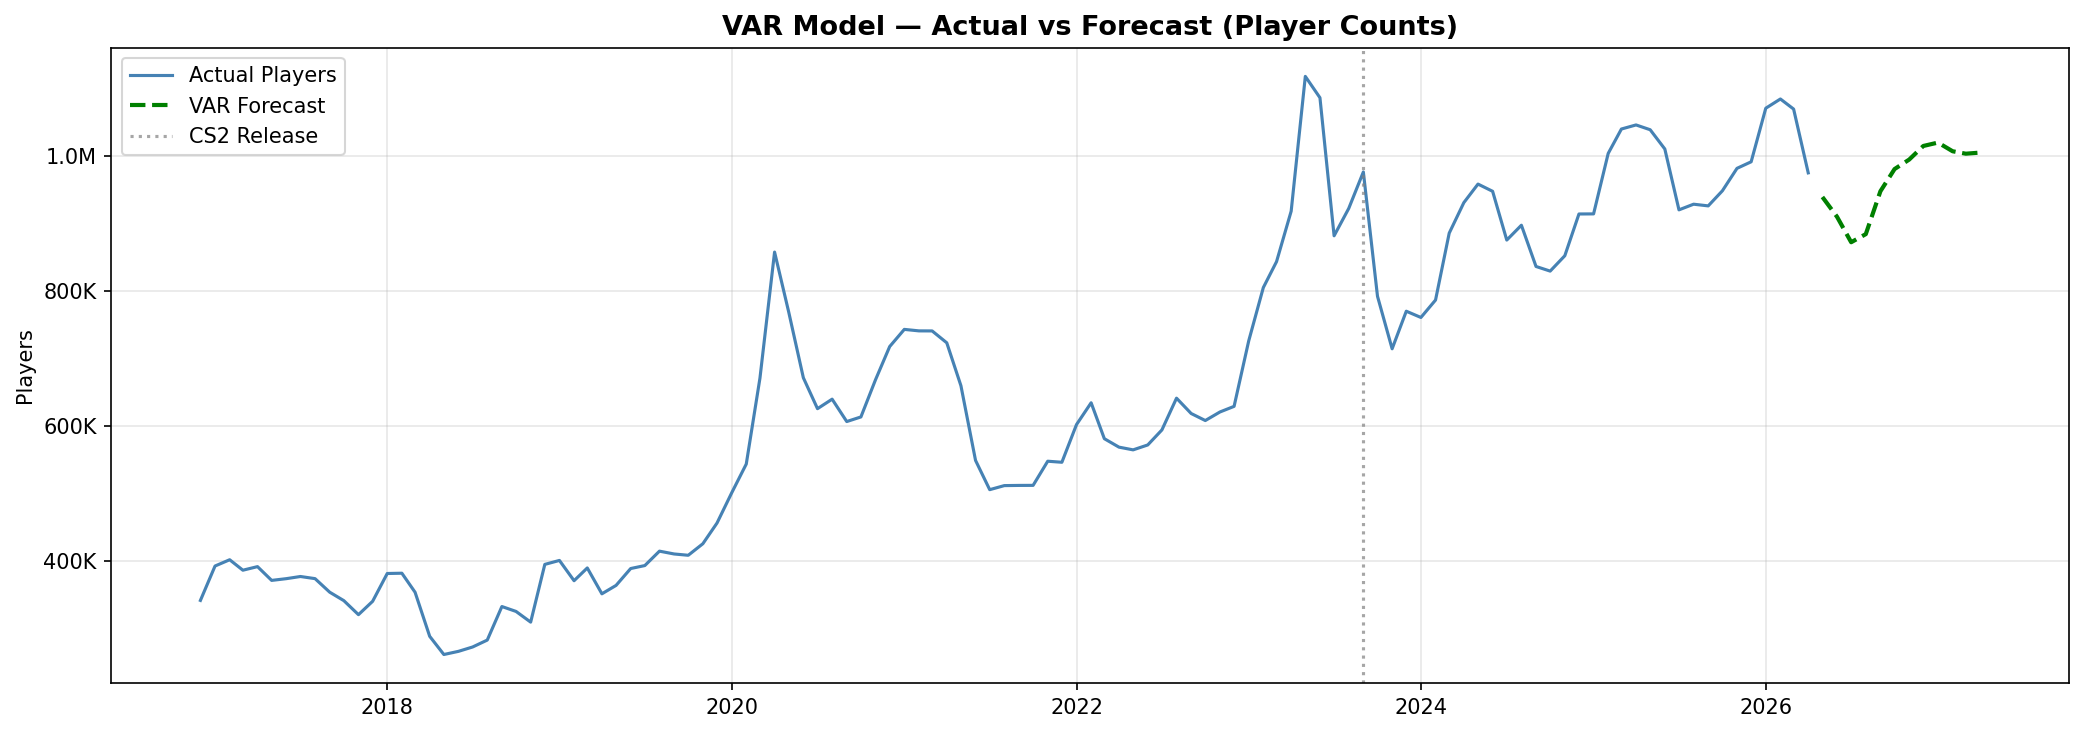

In [ ]:
display(Image("/content/var_forecast.png"))

The green dashed line shows the VAR model predicting a dip then recovery back to ~1M players — which actually makes more sense than ARIMA's flat line, because VAR is picking up the cyclical pattern from Twitch and Trends together.

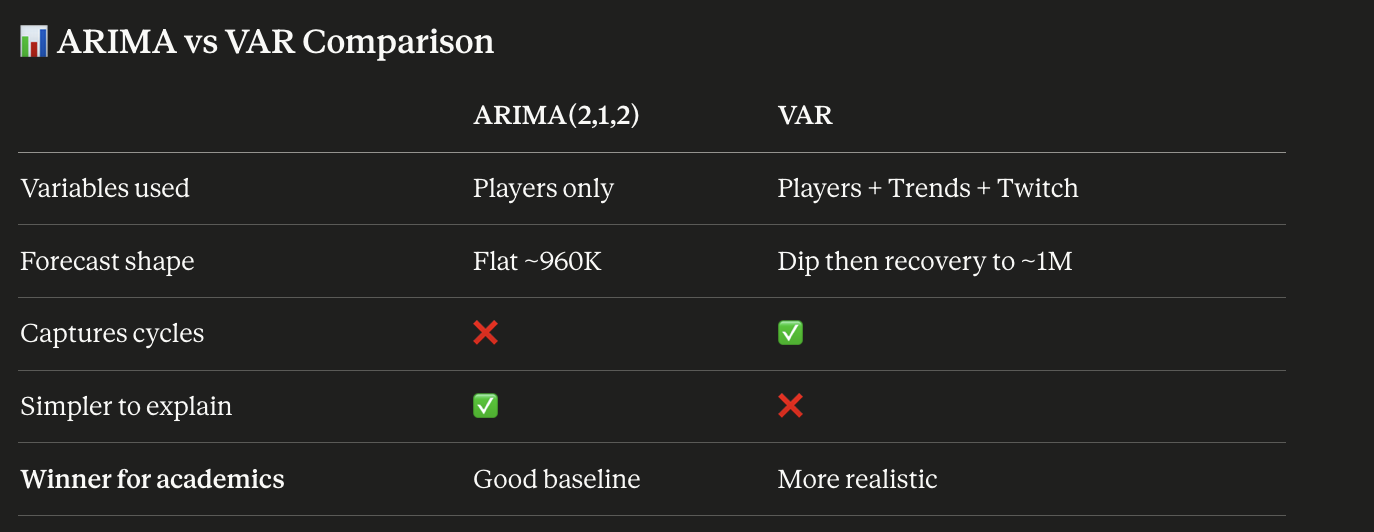

In [ ]:
# ─────────────────────────────────────────
# STEP 7: GARCH — Volatility Analysis
# ─────────────────────────────────────────

# pip install arch
from arch import arch_model
import numpy as np

# Use differenced Players, scaled down (GARCH works better on smaller numbers)
players_diff = df_full["Players"].diff().dropna()
players_scaled = players_diff / 1000  # scale to thousands

# Fit GARCH(1,1) — the standard starting model
garch = arch_model(players_scaled, vol="Garch", p=1, q=1, dist="normal")
garch_fitted = garch.fit(disp="off")

print(garch_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Players   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -818.536
Distribution:                  Normal   AIC:                           1645.07
Method:            Maximum Likelihood   BIC:                           1657.50
                                        No. Observations:                  165
Date:                Sun, May 03 2026   Df Residuals:                      164
Time:                        08:01:38   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             4.2894      1.751      2.450  1.428e-02 [  0.858,  7.72

In [ ]:
# --- Plot conditional volatility ---
vol = garch_fitted.conditional_volatility * 1000  # scale back

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    "GARCH(1,1) — Volatility Analysis of CS Player Counts",
    fontsize=13,
    fontweight="bold",
)

axes[0].plot(players_diff.index, players_diff, color="steelblue", linewidth=1)
axes[0].set_title("Monthly Change in Players (ΔPlayers)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

axes[1].plot(vol.index, vol, color="crimson", linewidth=1.5)
axes[1].set_title("Conditional Volatility (GARCH) — Uncertainty Over Time")
axes[1].set_ylabel("Volatility (players)")
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Mark key events
for ax in axes:
    ax.axvline(
        pd.Timestamp("2020-03-01"),
        color="orange",
        linestyle="--",
        alpha=0.7,
        label="COVID (Mar 2020)",
    )
    ax.axvline(
        pd.Timestamp("2023-09-01"),
        color="red",
        linestyle="--",
        alpha=0.7,
        label="CS2 Release",
    )

axes[0].legend(fontsize=8)
plt.tight_layout()
fig.savefig("garch_volatility.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ GARCH plot saved as garch_volatility.png")

✅ GARCH plot saved as garch_volatility.png


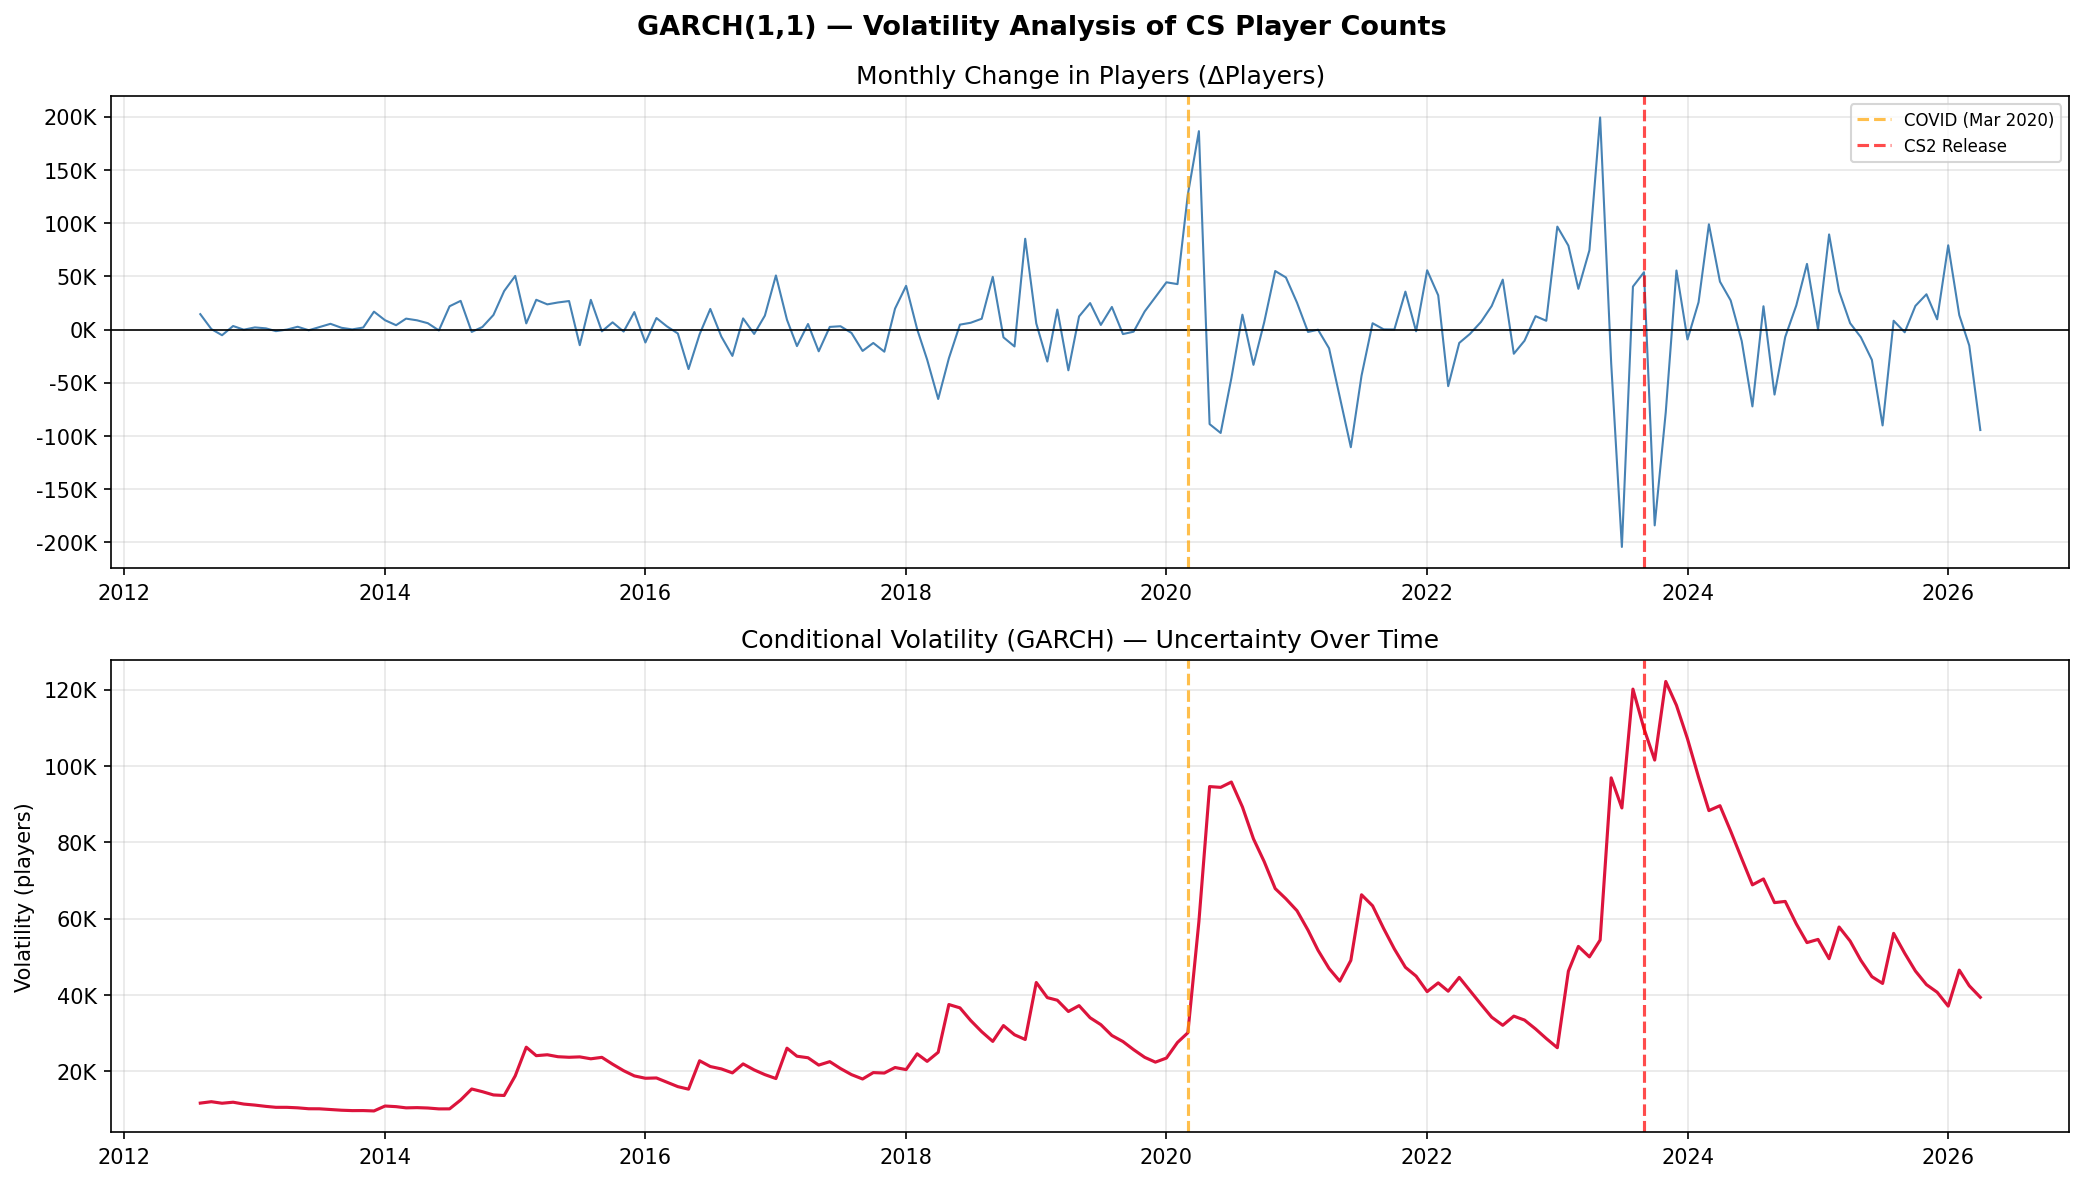

In [ ]:
display(Image("/content/garch_volatility.png"))

 Chart Interpretation:

*   2012–2019: Low, stable volatility (~15-25K) — the game was growing steadily
*   COVID spike (2020): Volatility jumps to ~95K — massive unexpected surge
*   Post-COVID: Settles down, then...
*   CS2 Release (2023): Biggest volatility spike ever — ~120K — the most disruptive event in the game's history
*   Now (2026): Volatility declining back to ~40K — market stabilizing




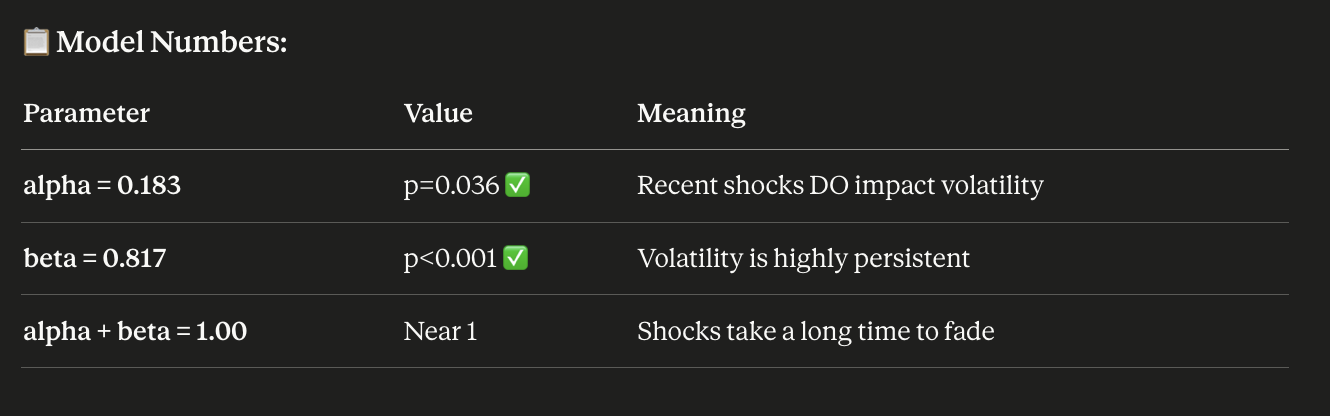

"GARCH(1,1) confirms significant volatility clustering (α=0.183, β=0.817). The near-unity persistence (α+β≈1.00) indicates that shocks such as the COVID lockdown and CS2 release have long-lasting effects on player count variability, with conditional volatility peaking at ~120K players around the CS2 launch period."

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────
st.set_page_config(
    page_title="CS2 Time Series Analysis",
    page_icon="🎮",
    layout="wide"
)

st.title("🎮 Counter-Strike Engagement — Time Series Analysis")
st.markdown("*Multivariate analysis of player counts, Google Trends & Twitch viewership (2012–2026)*")
st.divider()

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv('/content/Players - Sheet1.csv')
    df.columns = ['Month', 'Players', 'Date', 'Trends', 'Twitch']
    df['Twitch'] = df['Twitch'].astype(str).str.replace(',', '').str.strip()
    df['Twitch'] = pd.to_numeric(df['Twitch'], errors='coerce')
    df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
    df.set_index('Date', inplace=True)
    df = df[['Players', 'Trends', 'Twitch']].sort_index()
    return df

df = load_data()
df_full  = df[['Players', 'Trends']].copy()
df_multi = df.dropna(subset=['Twitch']).copy()

# ─────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────
st.sidebar.title("📂 Navigation")
section = st.sidebar.radio("Go to section:", [
    "📊 EDA Overview",
    "🧪 Stationarity (ADF Test)",
    "📈 ARIMA Forecast",
    "🔗 VAR + Granger Causality",
    "⚡ GARCH Volatility",
    "📋 Summary & Findings"
])

st.sidebar.divider()
st.sidebar.metric("Total Observations", f"{len(df)} months")
st.sidebar.metric("Date Range", f"Jul 2012 – Apr 2026")
st.sidebar.metric("Multivariate Period", f"{len(df_multi)} months")


def make_fig(figsize=(12, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax


# ─────────────────────────────────────────
# 1. EDA OVERVIEW
# ─────────────────────────────────────────
if section == "📊 EDA Overview":
    st.header("📊 Exploratory Data Analysis")

    col1, col2, col3 = st.columns(3)
    col1.metric("Peak Players", f"{df['Players'].max():,.0f}", "May 2023")
    col2.metric("Peak Trends", f"{df['Trends'].max()}", "Aug 2012")
    col3.metric("Peak Twitch", f"{df_multi['Twitch'].max():,.0f}", "")

    st.subheader("All Three Variables Over Time")
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

    axes[0].plot(df_full.index, df_full['Players'], color='#1f77b4', linewidth=1.5)
    axes[0].set_title('Avg. Monthly Players (Steam)')
    axes[0].set_ylabel('Players')
    axes[0].axvline(pd.Timestamp('2023-09-01'), color='red', linestyle='--', alpha=0.7, label='CS2 Release')
    axes[0].legend(fontsize=8)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_full.index, df_full['Trends'], color='#ff7f0e', linewidth=1.5)
    axes[1].set_title('Google Search Interest (0–100)')
    axes[1].set_ylabel('Trend Score')
    axes[1].axvline(pd.Timestamp('2023-09-01'), color='red', linestyle='--', alpha=0.7)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df_multi.index, df_multi['Twitch'], color='#9467bd', linewidth=1.5)
    axes[2].set_title('Avg. Twitch Viewers (from Dec 2016)')
    axes[2].set_ylabel('Viewers')
    axes[2].axvline(pd.Timestamp('2023-09-01'), color='red', linestyle='--', alpha=0.7)
    axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Correlation Matrix (2016–2026)")
    st.dataframe(df_multi[['Players', 'Trends', 'Twitch']].corr().round(3), use_container_width=True)

    st.info("""
    **Key Observations:**
    - 📈 Players show clear upward trend with COVID (2020) and CS2 (2023) spikes
    - 📉 Google Trends declining since 2012 — interest normalised as game matured
    - 🎮 Twitch shows cyclical spikes aligning with major tournaments
    """)


# ─────────────────────────────────────────
# 2. STATIONARITY
# ─────────────────────────────────────────
elif section == "🧪 Stationarity (ADF Test)":
    st.header("🧪 ADF Stationarity Test")

    def adf_result(series, name):
        r = adfuller(series.dropna())
        return {
            "Variable": name,
            "ADF Stat": round(r[0], 4),
            "p-value": round(r[1], 4),
            "Stationary?": "✅ Yes" if r[1] < 0.05 else "❌ No"
        }

    st.subheader("Original Series")
    orig = pd.DataFrame([
        adf_result(df_full['Players'], 'Players'),
        adf_result(df_full['Trends'],  'Trends'),
        adf_result(df_multi['Twitch'], 'Twitch'),
    ])
    st.dataframe(orig, use_container_width=True, hide_index=True)

    st.subheader("After 1st Differencing")
    diff = pd.DataFrame([
        adf_result(df_full['Players'].diff(), 'Players (d=1)'),
        adf_result(df_full['Trends'].diff(),  'Trends (d=1)'),
        adf_result(df_multi['Twitch'].diff(), 'Twitch (d=1)'),
    ])
    st.dataframe(diff, use_container_width=True, hide_index=True)

    st.subheader("Differenced Series Plot")
    fig, axes = plt.subplots(3, 1, figsize=(12, 7))
    axes[0].plot(df_full['Players'].diff(), color='#1f77b4', linewidth=1)
    axes[0].set_title('ΔPlayers'); axes[0].axhline(0, color='black', lw=0.8); axes[0].grid(True, alpha=0.3)
    axes[1].plot(df_full['Trends'].diff(), color='#ff7f0e', linewidth=1)
    axes[1].set_title('ΔTrends'); axes[1].axhline(0, color='black', lw=0.8); axes[1].grid(True, alpha=0.3)
    axes[2].plot(df_multi['Twitch'].diff(), color='#9467bd', linewidth=1)
    axes[2].set_title('ΔTwitch'); axes[2].axhline(0, color='black', lw=0.8); axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    st.success("✅ All series become stationary after one round of differencing → d = 1 for Players and Twitch, d = 0 for Trends")


# ─────────────────────────────────────────
# 3. ARIMA
# ─────────────────────────────────────────
elif section == "📈 ARIMA Forecast":
    st.header("📈 ARIMA(2,1,2) — Univariate Forecast")

    with st.spinner("Fitting ARIMA model..."):
        players = df_full['Players']
        model = ARIMA(players, order=(2, 1, 2))
        fitted = model.fit()

        forecast = fitted.get_forecast(steps=12)
        fc_mean = forecast.predicted_mean
        fc_ci   = forecast.conf_int()

    col1, col2, col3 = st.columns(3)
    col1.metric("Model", "ARIMA(2,1,2)")
    col2.metric("AIC", f"{fitted.aic:.2f}")
    col3.metric("12-Month Avg Forecast", f"{fc_mean.mean():,.0f}")

    st.subheader("Actual vs Forecast")
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(players.index, players, label='Actual Players', color='steelblue', linewidth=1.5)
    ax.plot(fc_mean.index, fc_mean, label='Forecast', color='red', linewidth=2, linestyle='--')
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color='red', alpha=0.15, label='95% CI')
    ax.axvline(pd.Timestamp('2023-09-01'), color='gray', linestyle=':', alpha=0.7, label='CS2 Release')
    ax.set_ylabel('Players')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("12-Month Forecast Values")
    fc_df = pd.DataFrame({'Month': fc_mean.index.strftime('%b %Y'), 'Forecast Players': fc_mean.values.round(0).astype(int)})
    st.dataframe(fc_df, use_container_width=True, hide_index=True)

    st.subheader("Residual Diagnostics")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(fitted.resid, color='steelblue', linewidth=1)
    axes[0].axhline(0, color='black', lw=0.8); axes[0].set_title('Residuals over Time'); axes[0].grid(True, alpha=0.3)
    plot_acf(fitted.resid, lags=24, ax=axes[1], title='ACF of Residuals')
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    st.info("✅ Residuals show no significant autocorrelation — model has captured the key patterns.")


# ─────────────────────────────────────────
# 4. VAR + GRANGER
# ─────────────────────────────────────────
elif section == "🔗 VAR + Granger Causality":
    st.header("🔗 VAR Model + Granger Causality")

    var_data = df_multi[['Players', 'Trends', 'Twitch']].diff().dropna()

    with st.spinner("Fitting VAR model..."):
        model_var  = VAR(var_data)
        lag_sel    = model_var.select_order(maxlags=12)
        best_lag   = lag_sel.selected_orders['aic']
        var_fitted = model_var.fit(best_lag)

    col1, col2, col3 = st.columns(3)
    col1.metric("Best Lag (AIC)", best_lag)
    col2.metric("Variables", "Players, Trends, Twitch")
    col3.metric("Sample Period", "Jan 2017 – Apr 2026")

    # VAR Forecast
    st.subheader("VAR Forecast — Player Counts")
    fc_raw  = var_fitted.forecast(var_data.values[-best_lag:], steps=12)
    fc_df2  = pd.DataFrame(fc_raw, columns=['ΔPlayers', 'ΔTrends', 'ΔTwitch'])
    last_val = df_multi['Players'].iloc[-1]
    last_dt  = df_multi.index[-1]
    fc_dates = pd.date_range(start=last_dt + pd.DateOffset(months=1), periods=12, freq='MS')
    actual_fc = [last_val]
    for d in fc_df2['ΔPlayers']:
        actual_fc.append(actual_fc[-1] + d)
    actual_fc = actual_fc[1:]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(df_multi.index, df_multi['Players'], label='Actual Players', color='steelblue', linewidth=1.5)
    ax.plot(fc_dates, actual_fc, label='VAR Forecast', color='green', linewidth=2, linestyle='--')
    ax.axvline(pd.Timestamp('2023-09-01'), color='gray', linestyle=':', alpha=0.7, label='CS2 Release')
    ax.set_ylabel('Players')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    # Granger Causality
    st.subheader("Granger Causality Results")

    def granger_summary(data, maxlag):
        rows = []
        gc = grangercausalitytests(data, maxlag=maxlag, verbose=False)
        for lag, res in gc.items():
            p = res[0]['ssr_ftest'][1]
            rows.append({"Lag": lag, "p-value": round(p, 4), "Significant (p<0.05)?": "✅ Yes" if p < 0.05 else "❌ No"})
        return pd.DataFrame(rows)

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Does Trends → cause → Players?**")
        st.dataframe(granger_summary(var_data[['Players', 'Trends']], best_lag), hide_index=True, use_container_width=True)
    with col2:
        st.markdown("**Does Twitch → cause → Players?**")
        st.dataframe(granger_summary(var_data[['Players', 'Twitch']], best_lag), hide_index=True, use_container_width=True)

    st.success("✅ Google Trends Granger-causes Players at lags 3–5 (p<0.05). Twitch shows no significant causality at any lag.")


# ─────────────────────────────────────────
# 5. GARCH
# ─────────────────────────────────────────
elif section == "⚡ GARCH Volatility":
    st.header("⚡ GARCH(1,1) — Volatility Analysis")

    with st.spinner("Fitting GARCH model..."):
        players_diff   = df_full['Players'].diff().dropna()
        players_scaled = players_diff / 1000
        garch     = arch_model(players_scaled, vol='Garch', p=1, q=1, dist='normal')
        garch_fit = garch.fit(disp='off')
        vol       = garch_fit.conditional_volatility * 1000

    params = garch_fit.params
    col1, col2, col3 = st.columns(3)
    col1.metric("Alpha (α)", f"{params['alpha[1]']:.4f}", "Short-term shock impact")
    col2.metric("Beta (β)", f"{params['beta[1]']:.4f}", "Volatility persistence")
    col3.metric("α + β", f"{params['alpha[1]'] + params['beta[1]']:.4f}", "Near 1 = long memory")

    fig, axes = plt.subplots(2, 1, figsize=(13, 8))
    axes[0].plot(players_diff.index, players_diff, color='steelblue', linewidth=1)
    axes[0].set_title('Monthly Change in Players (ΔPlayers)')
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.7, label='COVID')
    axes[0].axvline(pd.Timestamp('2023-09-01'), color='red',    linestyle='--', alpha=0.7, label='CS2 Release')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

    axes[1].plot(vol.index, vol, color='crimson', linewidth=1.5)
    axes[1].set_title('Conditional Volatility — Uncertainty Over Time')
    axes[1].set_ylabel('Volatility (players)')
    axes[1].axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.7, label='COVID')
    axes[1].axvline(pd.Timestamp('2023-09-01'), color='red',    linestyle='--', alpha=0.7, label='CS2 Release')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    st.info("""
    **Key Findings:**
    - 📉 Low stable volatility (2012–2019): ~15–25K/month
    - 🦠 COVID (2020): Volatility spikes to ~95K
    - 🎮 CS2 Release (2023): Highest ever spike ~120K — most disruptive event
    - 📉 Volatility now declining back to ~40K — market stabilising
    """)


# ─────────────────────────────────────────
# 6. SUMMARY
# ─────────────────────────────────────────
elif section == "📋 Summary & Findings":
    st.header("📋 Summary of Findings")

    st.subheader("🔬 Methods Used")
    methods = pd.DataFrame({
        "Method": ["ADF Test", "ARIMA(2,1,2)", "VAR", "Granger Causality", "GARCH(1,1)"],
        "Purpose": ["Stationarity testing", "Univariate forecasting", "Multivariate forecasting", "Causality between variables", "Volatility modelling"],
        "Key Result": [
            "All stationary after d=1",
            "AIC=3995.44, forecasts ~960K players",
            "Predicts dip then recovery to ~1M",
            "Trends → Players (p<0.05 at lag 3–5)",
            "α+β≈1, CS2 caused peak volatility"
        ]
    })
    st.dataframe(methods, use_container_width=True, hide_index=True)

    st.subheader("💡 Key Insights")
    st.markdown("""
    1. **CS2 release (Sep 2023) was the biggest structural break** — player counts surged and volatility peaked at ~120K/month
    2. **Google Search Interest predicts player counts** with a 3–5 month lag — useful for early warning of engagement changes
    3. **Twitch viewership does not Granger-cause player counts** — watching and playing are independent behaviors
    4. **Volatility is highly persistent (α+β≈1)** — shocks like COVID and CS2 take a long time to fade from the system
    5. **VAR outperforms ARIMA** in capturing cyclical patterns by incorporating cross-variable information
    """)

    st.subheader("📁 Datasets")
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Full Dataset (Players + Trends)**")
        st.dataframe(df_full.tail(10), use_container_width=True)
    with col2:
        st.markdown("**Multivariate Dataset (+ Twitch)**")
        st.dataframe(df_multi.tail(10), use_container_width=True)

Overwriting app.py
